<a href="https://colab.research.google.com/github/santiagoramosg/ia/blob/main/M%C3%A9tricas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

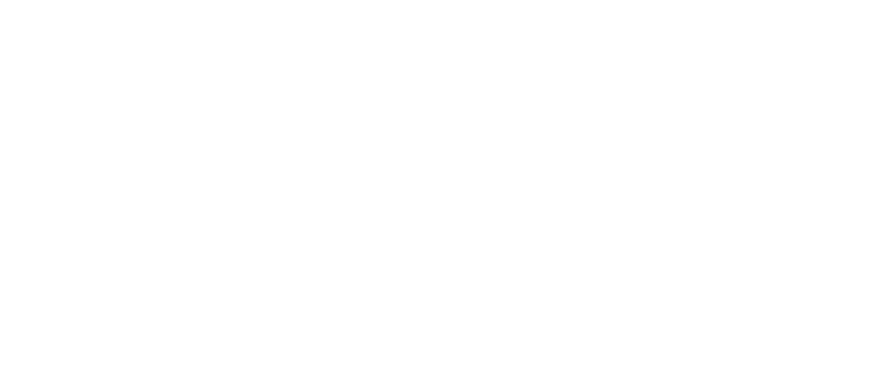

# Taller Introducción a la IA: Métricas Aprendizaje Supervisado


## No olvide escribir su correo y nombre, para la entrega del taller y posterior calificación

In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    silhouette_score,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Creamos el dataset

In [2]:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_classes=2, random_state=42)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Creamos el modelo

In [4]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [5]:
y_pred = svm_model.predict(X_test)

In [6]:
cm = confusion_matrix(y_test, y_pred)

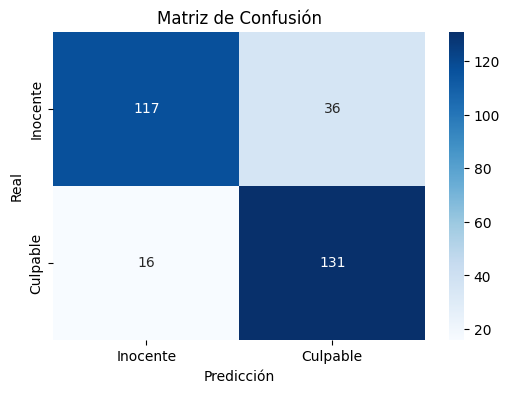

In [7]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Inocente", "Culpable"], yticklabels=["Inocente", "Culpable"])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

In [8]:
VP = cm[0,0]  # Verdaderos Positivos
FN = cm[0,1]  # Falsos Negativos
FP = cm[1,0]  # Falsos Positivos
VN = cm[1,1]  # Verdaderos Negativos

print(f"VP: {VP}")
print(f"FN: {FN}")
print(f"FP: {FP}")
print(f"VN: {VN}")

VP: 117
FN: 36
FP: 16
VN: 131


In [9]:
# Utilizando las variables anteriores:

accuracy = (VP+VN)/(VP+VN+FP+FN)  # Completa la fórmula para la exactitud (accuracy)
precision = VP/(VP+FP)  # Completa la fórmula para la precisión (precision)
recall = VP/(VP+FN) # Completa la fórmula para el recall
f1_score = 2*((precision*recall)/(precision+recall)) # Completa la fórmula para el F1-score
fpr=FP/(FP+VN)

In [10]:
print(f"Exactitud (Accuracy): {accuracy:.2f}")
print(f"Precisión (Precision): {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")

Exactitud (Accuracy): 0.83
Precisión (Precision): 0.88
Recall: 0.76
F1-Score: 0.82


In [11]:
"""
Importante tener en cuenta que lo anterior se puede obtener facilmente usando la función classification_report


from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

"""

'\nImportante tener en cuenta que lo anterior se puede obtener facilmente usando la función classification_report\n\n\nfrom sklearn.metrics import classification_report\n\nprint(classification_report(y_test, y_pred))\n\n'

In [12]:
# Obtener puntajes de decisión o probabilidades para la clase positiva
# (completa con decision_function o predict_proba)
y_scores = svm_model.decision_function(X_test)

In [13]:
df_scores = pd.DataFrame(y_scores, columns=["Score"])
print(df_scores.head())

      Score
0  2.062054
1 -4.081137
2 -3.131730
3  0.533541
4 -3.288151


In [14]:
# Calcular los valores de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test,y_pred)

In [15]:
# Calcular el AUC (Área bajo la curva)
auc_score = roc_auc_score(y_test, y_pred)

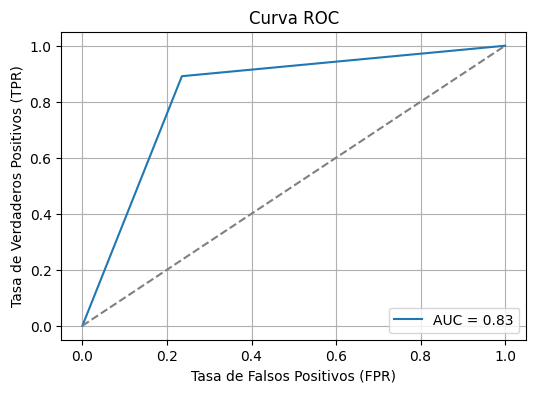

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [17]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_scores)

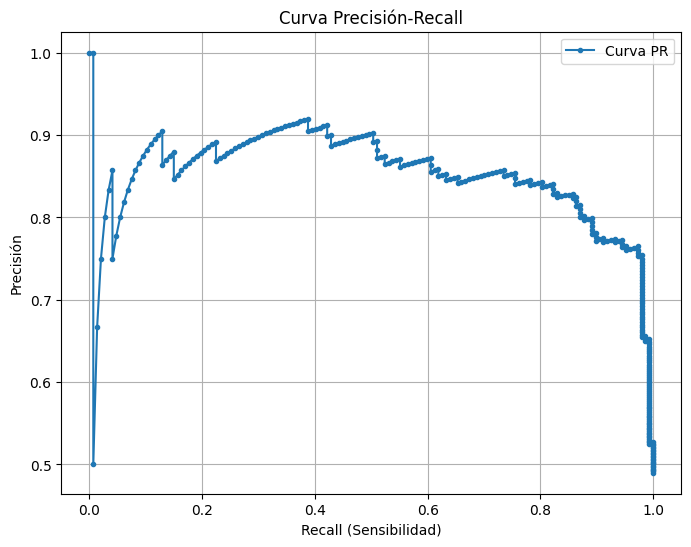

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='Curva PR')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curva Precisión-Recall')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
auc_pr = auc(recall, precision)
print(f"Área Bajo la Curva PR (AUC-PR): {auc_pr:.4f}")

Área Bajo la Curva PR (AUC-PR): 0.8504


# **PREGUNTAS**




1. **¿Cuál fue el valor del recall?**  
el recall tuvo un valor de 0.76 significando un 76.47% de precision al detectar inocentes



2. **¿En qué situación podría ser preferible
tener un modelo con alto recall pero baja precisión en este concurso de detectives? ¿Deberías desconfiar en el modelo a pesar del buen recall? Justifica tu respuesta en el contexto del problema.**  

un alto recall puede ser preferible si se considera que es preferible un falso negativo a un falso positivo en este caso  
sin embargo estos modelos al tener un recall alto posee una precision deficiente

3. **Si el organizador del concurso cambia las reglas para penalizar más los falsos positivos que los falsos negativos, ¿qué métrica deberías optimizar y por qué?**

se deberia optimizar es la precision dado que es la que mide la precision al acusar inocentes

4. **Si decides comparar varios modelos utilizando la curva ROC y el AUC y la curva PR y , ¿qué representa esta métrica en el contexto del concurso? ¿Por qué podría ser más útil que el accuracy cuando las clases están desbalanceadas (pocos culpables y muchos inocentes en el conjunto de datos)?**  

el ROC representa la relación entre culpables bien identificados e inocentes acusados indebidamente, el UAC representa el area bajo esa curva, significando la precision de correcta discriminacion, y la curva PR es la relacion entre el precision y el recall  

es mejor el ROC y el PR dado que si las clases son muy desbalanceadas, el modelo probablemente prediga incorrectamente la clase con menos datos

5. **¿Por qué el F1-Score se considera una de las métricas más importantes para evaluar modelos de clasificación?**  

es importante dado que es la medida que involucra el precision y el recall, siendo robusto al desbalance de datos y dando un equilibrio en las metricas